# Customer Churn Prediction & Analytics
# Exploratory Data Analysis (EDA)

# Step 1 → Read Data

In [1]:
import pandas as pd

df = pd.read_csv("customer_churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Step 2 → Data Quick Check

In [2]:
print("Shape:", df.shape)
print("Size:", df.size)
print("Length:", len(df))
df.head()

Shape: (7043, 21)
Size: 147903
Length: 7043


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Step 3 → Numerical & Categorical Columns

In [3]:
# Data type of each column
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [4]:
# Numerical columns
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

# Categorical columns
categorical_columns = df.select_dtypes(include=["object"]).columns

print("Numerical Columns:")
print(numerical_columns.tolist())

print("\nCategorical Columns:")
print(categorical_columns.tolist())


Numerical Columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges']

Categorical Columns:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


# Step 4 → Missing Value Analysis

In [5]:
# Check missing values in each column
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
# Check blank/empty values in object columns

(df.select_dtypes(include="object") == " ").sum()

customerID           0
gender               0
Partner              0
Dependents           0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
TotalCharges        11
Churn                0
dtype: int64

# Step 5 → Duplicate Analysis

In [7]:
# Check total duplicate rows
df.duplicated().sum()

np.int64(0)

# Step 6 → Statistical Analysis

In [8]:
# Generate statistical summary of numerical columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


# Step 7 → Outlier Analysis

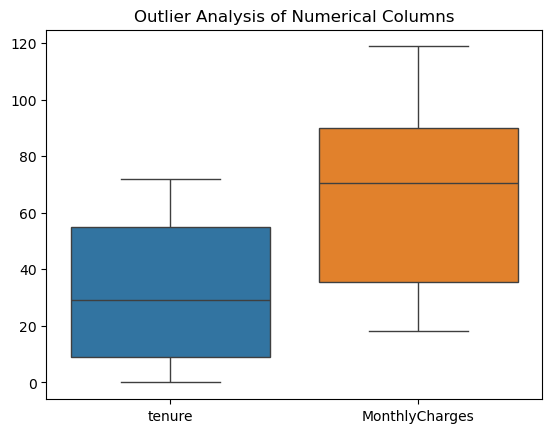

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Boxplot for numerical columns
sns.boxplot(data=df[["tenure", "MonthlyCharges", "TotalCharges"]])

plt.title("Outlier Analysis of Numerical Columns")
plt.show()

# Step 8 → Univariate Analysis

In [10]:
# Churn Distribution
print(df["Churn"].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [11]:
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


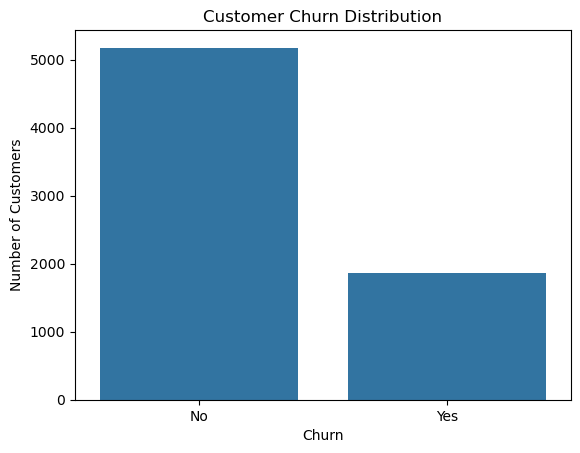

In [12]:
# Churn Distribution Plot

sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

# Step 8.2 → Univariate Analysis → Gender

gender
Male      3555
Female    3488
Name: count, dtype: int64
gender
Male      50.47565
Female    49.52435
Name: proportion, dtype: float64


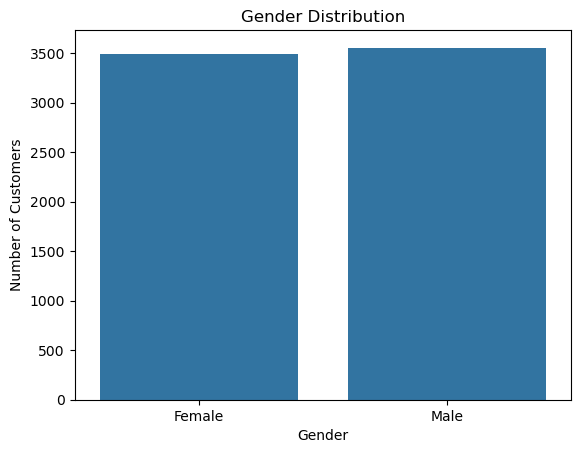

In [13]:
# Count of each gender
print(df["gender"].value_counts())

# Percentage of each gender
print(df["gender"].value_counts(normalize=True) * 100)

# Visualization
sns.countplot(x="gender", data=df)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

# Step 8.3 → Univariate Analysis → Contract

In [14]:
# Count of each contract type
contract_count = df["Contract"].value_counts()

print("Contract Distribution:")
print(contract_count)

# Percentage of each contract type
print("\nContract Percentage:")
print((contract_count / len(df) * 100).round(2))


Contract Distribution:
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

Contract Percentage:
Contract
Month-to-month    55.02
Two year          24.07
One year          20.91
Name: count, dtype: float64


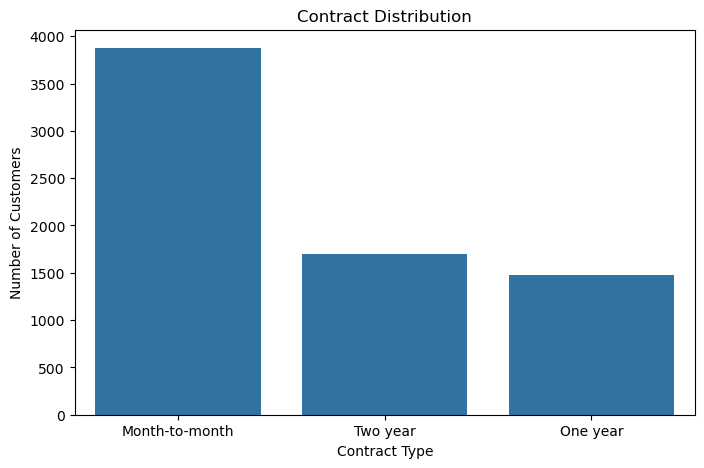

In [15]:
# Contract Distribution Plot

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Contract",
    order=df["Contract"].value_counts().index
)

plt.title("Contract Distribution")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.show()

# Step 8.4 → Univariate Analysis → InternetService

Internet Service Distribution:
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

Internet Service Percentage:
InternetService
Fiber optic    43.96%
DSL            34.37%
No             21.67%
Name: proportion, dtype: object


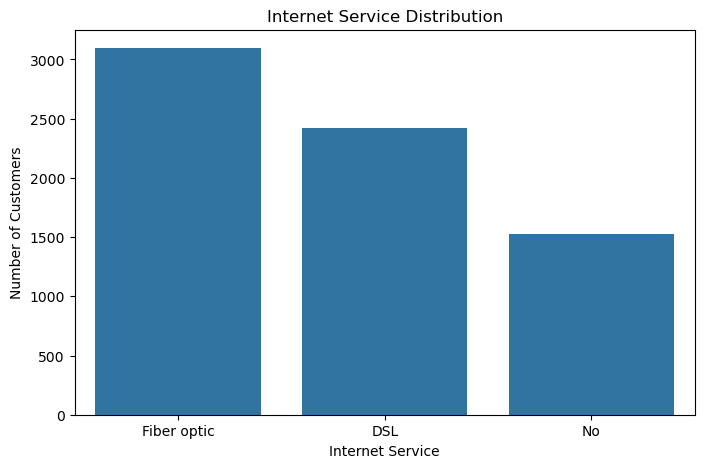

In [16]:
# Internet Service Count
internet_count = df["InternetService"].value_counts()

print("Internet Service Distribution:")
print(internet_count)

print("\nInternet Service Percentage:")
print(
    df["InternetService"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .astype(str) + "%"
)

# Visualization
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="InternetService",
    order=df["InternetService"].value_counts().index
)

plt.title("Internet Service Distribution")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

# Step 8.5 → Univariate Analysis → PaymentMethod

In [17]:
# Payment Method Count
payment_count = df["PaymentMethod"].value_counts()

print("Payment Method Distribution:")
print(payment_count)

print("\nPayment Method Percentage:")
print(
    df["PaymentMethod"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .astype(str) + "%"
)

Payment Method Distribution:
PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

Payment Method Percentage:
PaymentMethod
Electronic check             33.58%
Mailed check                 22.89%
Bank transfer (automatic)    21.92%
Credit card (automatic)      21.61%
Name: proportion, dtype: object


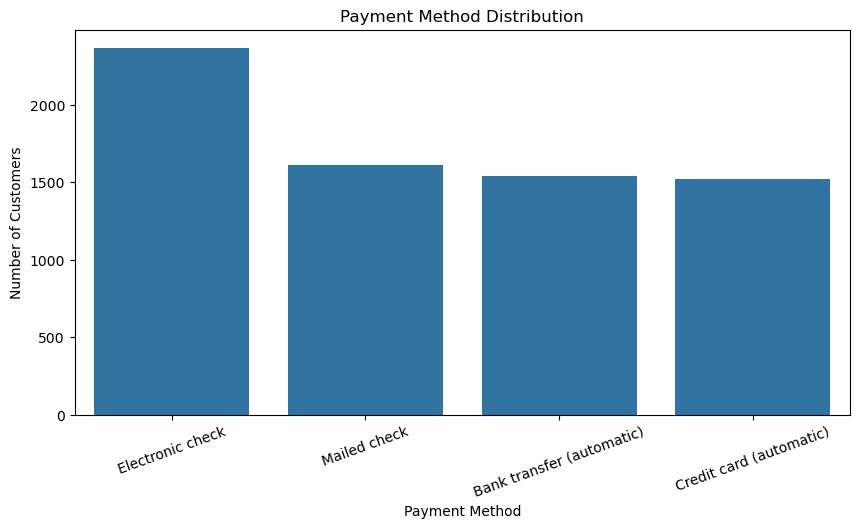

In [18]:
# Visualization
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="PaymentMethod",
    order=df["PaymentMethod"].value_counts().index
)

plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

plt.show()

# Step 8.6 → Univariate Analysis → SeniorCitizen

In [19]:
# Senior Citizen Count
senior_count = df["SeniorCitizen"].value_counts()

print("Senior Citizen Distribution:")
print(senior_count)

print("\nSenior Citizen Percentage:")
print(
    df["SeniorCitizen"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .astype(str) + "%"
)

Senior Citizen Distribution:
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

Senior Citizen Percentage:
SeniorCitizen
0    83.79%
1    16.21%
Name: proportion, dtype: object


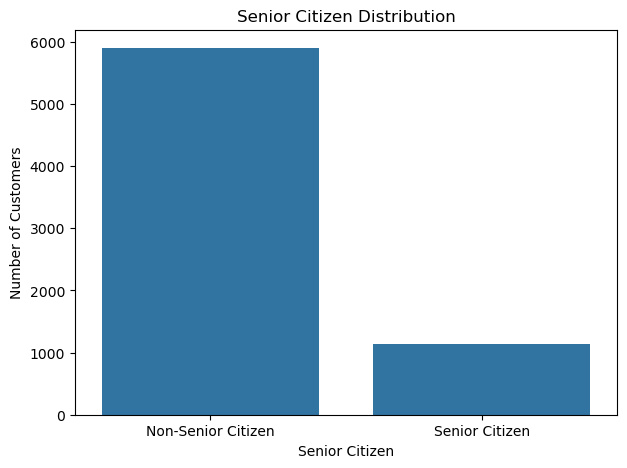

In [20]:
# Visualization
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="SeniorCitizen"
)

plt.title("Senior Citizen Distribution")
plt.xlabel("Senior Citizen")
plt.ylabel("Number of Customers")

plt.xticks([0, 1], ["Non-Senior Citizen", "Senior Citizen"])

plt.show()

# Step 8.7 → Univariate Analysis → Tenure

Tenure Statistics:
count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64


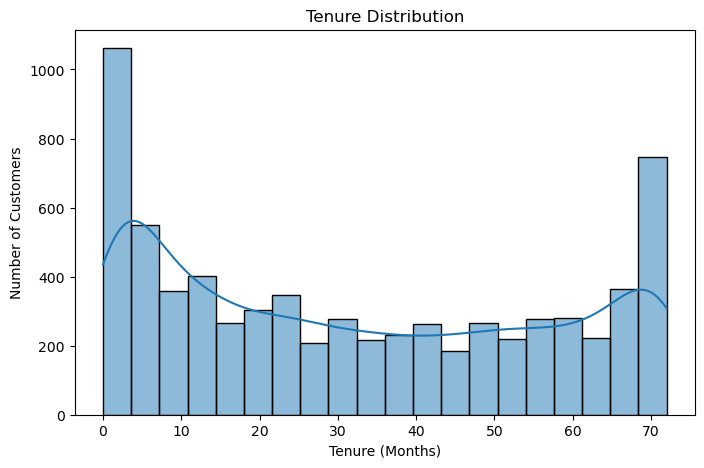

In [21]:
# Statistical summary
print("Tenure Statistics:")
print(df["tenure"].describe())

# Histogram
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="tenure",
    bins=20,
    kde=True
)

plt.title("Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

# Step 8.8 → Univariate Analysis → MonthlyCharges

Monthly Charges Statistics:
count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64


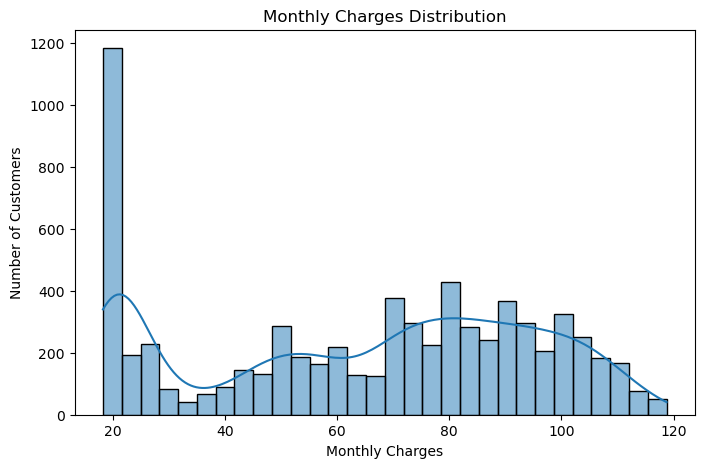

In [22]:
# Statistical summary
print("Monthly Charges Statistics:")
print(df["MonthlyCharges"].describe())

# Histogram
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="MonthlyCharges",
    bins=30,
    kde=True
)

plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.show()

# Step 8.9 → Univariate Analysis → TotalCharges

In [23]:
# Check TotalCharges data type
print("Data Type:")
print(df["TotalCharges"].dtype)

# Check missing values
print("\nMissing Values:")
print(df["TotalCharges"].isnull().sum())

# Check first few values
print("\nSample Values:")
print(df["TotalCharges"].head(10))

Data Type:
object

Missing Values:
0

Sample Values:
0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: object


# Step 9.1 → Bivariate Analysis → Gender vs Churn

In [24]:
# Count of Gender vs Churn
print(pd.crosstab(df["gender"], df["Churn"]))

# Churn percentage by gender
gender_churn = pd.crosstab(
    df["gender"],
    df["Churn"],
    normalize="index"
) * 100

print("\nChurn Percentage by Gender:")
print(gender_churn.round(2))

Churn     No  Yes
gender           
Female  2549  939
Male    2625  930

Churn Percentage by Gender:
Churn      No    Yes
gender              
Female  73.08  26.92
Male    73.84  26.16


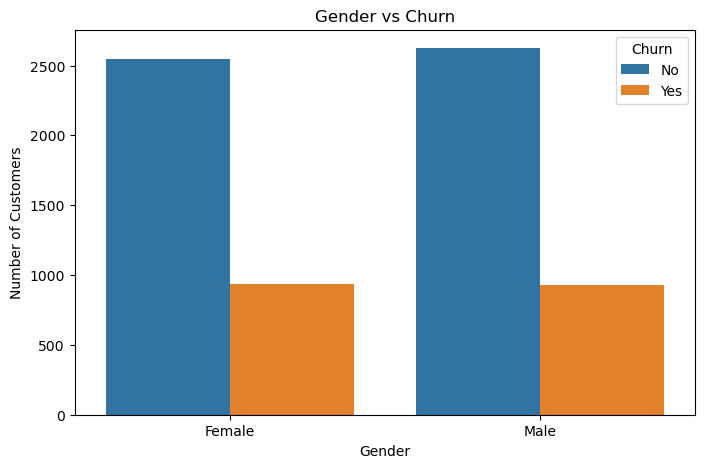

In [25]:
# Gender vs Churn Plot

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="gender",
    hue="Churn"
)

plt.title("Gender vs Churn")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

# Step 9.2 → Bivariate Analysis → Contract vs Churn

In [26]:
# Contract vs Churn Count
print(pd.crosstab(df["Contract"], df["Churn"]))

# Churn percentage by Contract
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print("\nChurn Percentage by Contract:")
print(contract_churn.round(2))

Churn             No   Yes
Contract                  
Month-to-month  2220  1655
One year        1307   166
Two year        1647    48

Churn Percentage by Contract:
Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


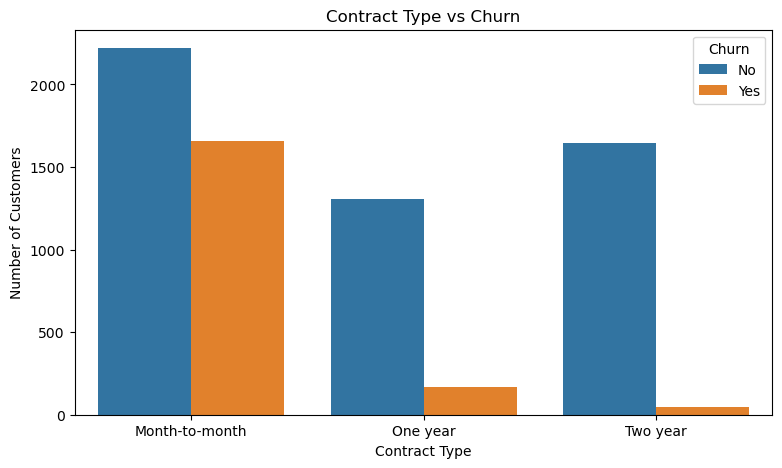

In [27]:
# Contract vs Churn Plot

plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Contract Type vs Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

In [28]:
# Categorical Features vs Churn

categorical_features = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

for column in categorical_features:
    print("\n" + "=" * 60)
    print(f"{column} vs Churn")
    print("=" * 60)

    print(
        pd.crosstab(
            df[column],
            df["Churn"],
            normalize="index"
        ).round(2) * 100
    )


gender vs Churn
Churn     No   Yes
gender            
Female  73.0  27.0
Male    74.0  26.0

SeniorCitizen vs Churn
Churn            No   Yes
SeniorCitizen            
0              76.0  24.0
1              58.0  42.0

Partner vs Churn
Churn      No   Yes
Partner            
No       67.0  33.0
Yes      80.0  20.0

Dependents vs Churn
Churn         No   Yes
Dependents            
No          69.0  31.0
Yes         85.0  15.0

PhoneService vs Churn
Churn           No   Yes
PhoneService            
No            75.0  25.0
Yes           73.0  27.0

InternetService vs Churn
Churn              No   Yes
InternetService            
DSL              81.0  19.0
Fiber optic      58.0  42.0
No               93.0   7.0

OnlineSecurity vs Churn
Churn                  No   Yes
OnlineSecurity                 
No                   58.0  42.0
No internet service  93.0   7.0
Yes                  85.0  15.0

OnlineBackup vs Churn
Churn                  No   Yes
OnlineBackup                   
No     

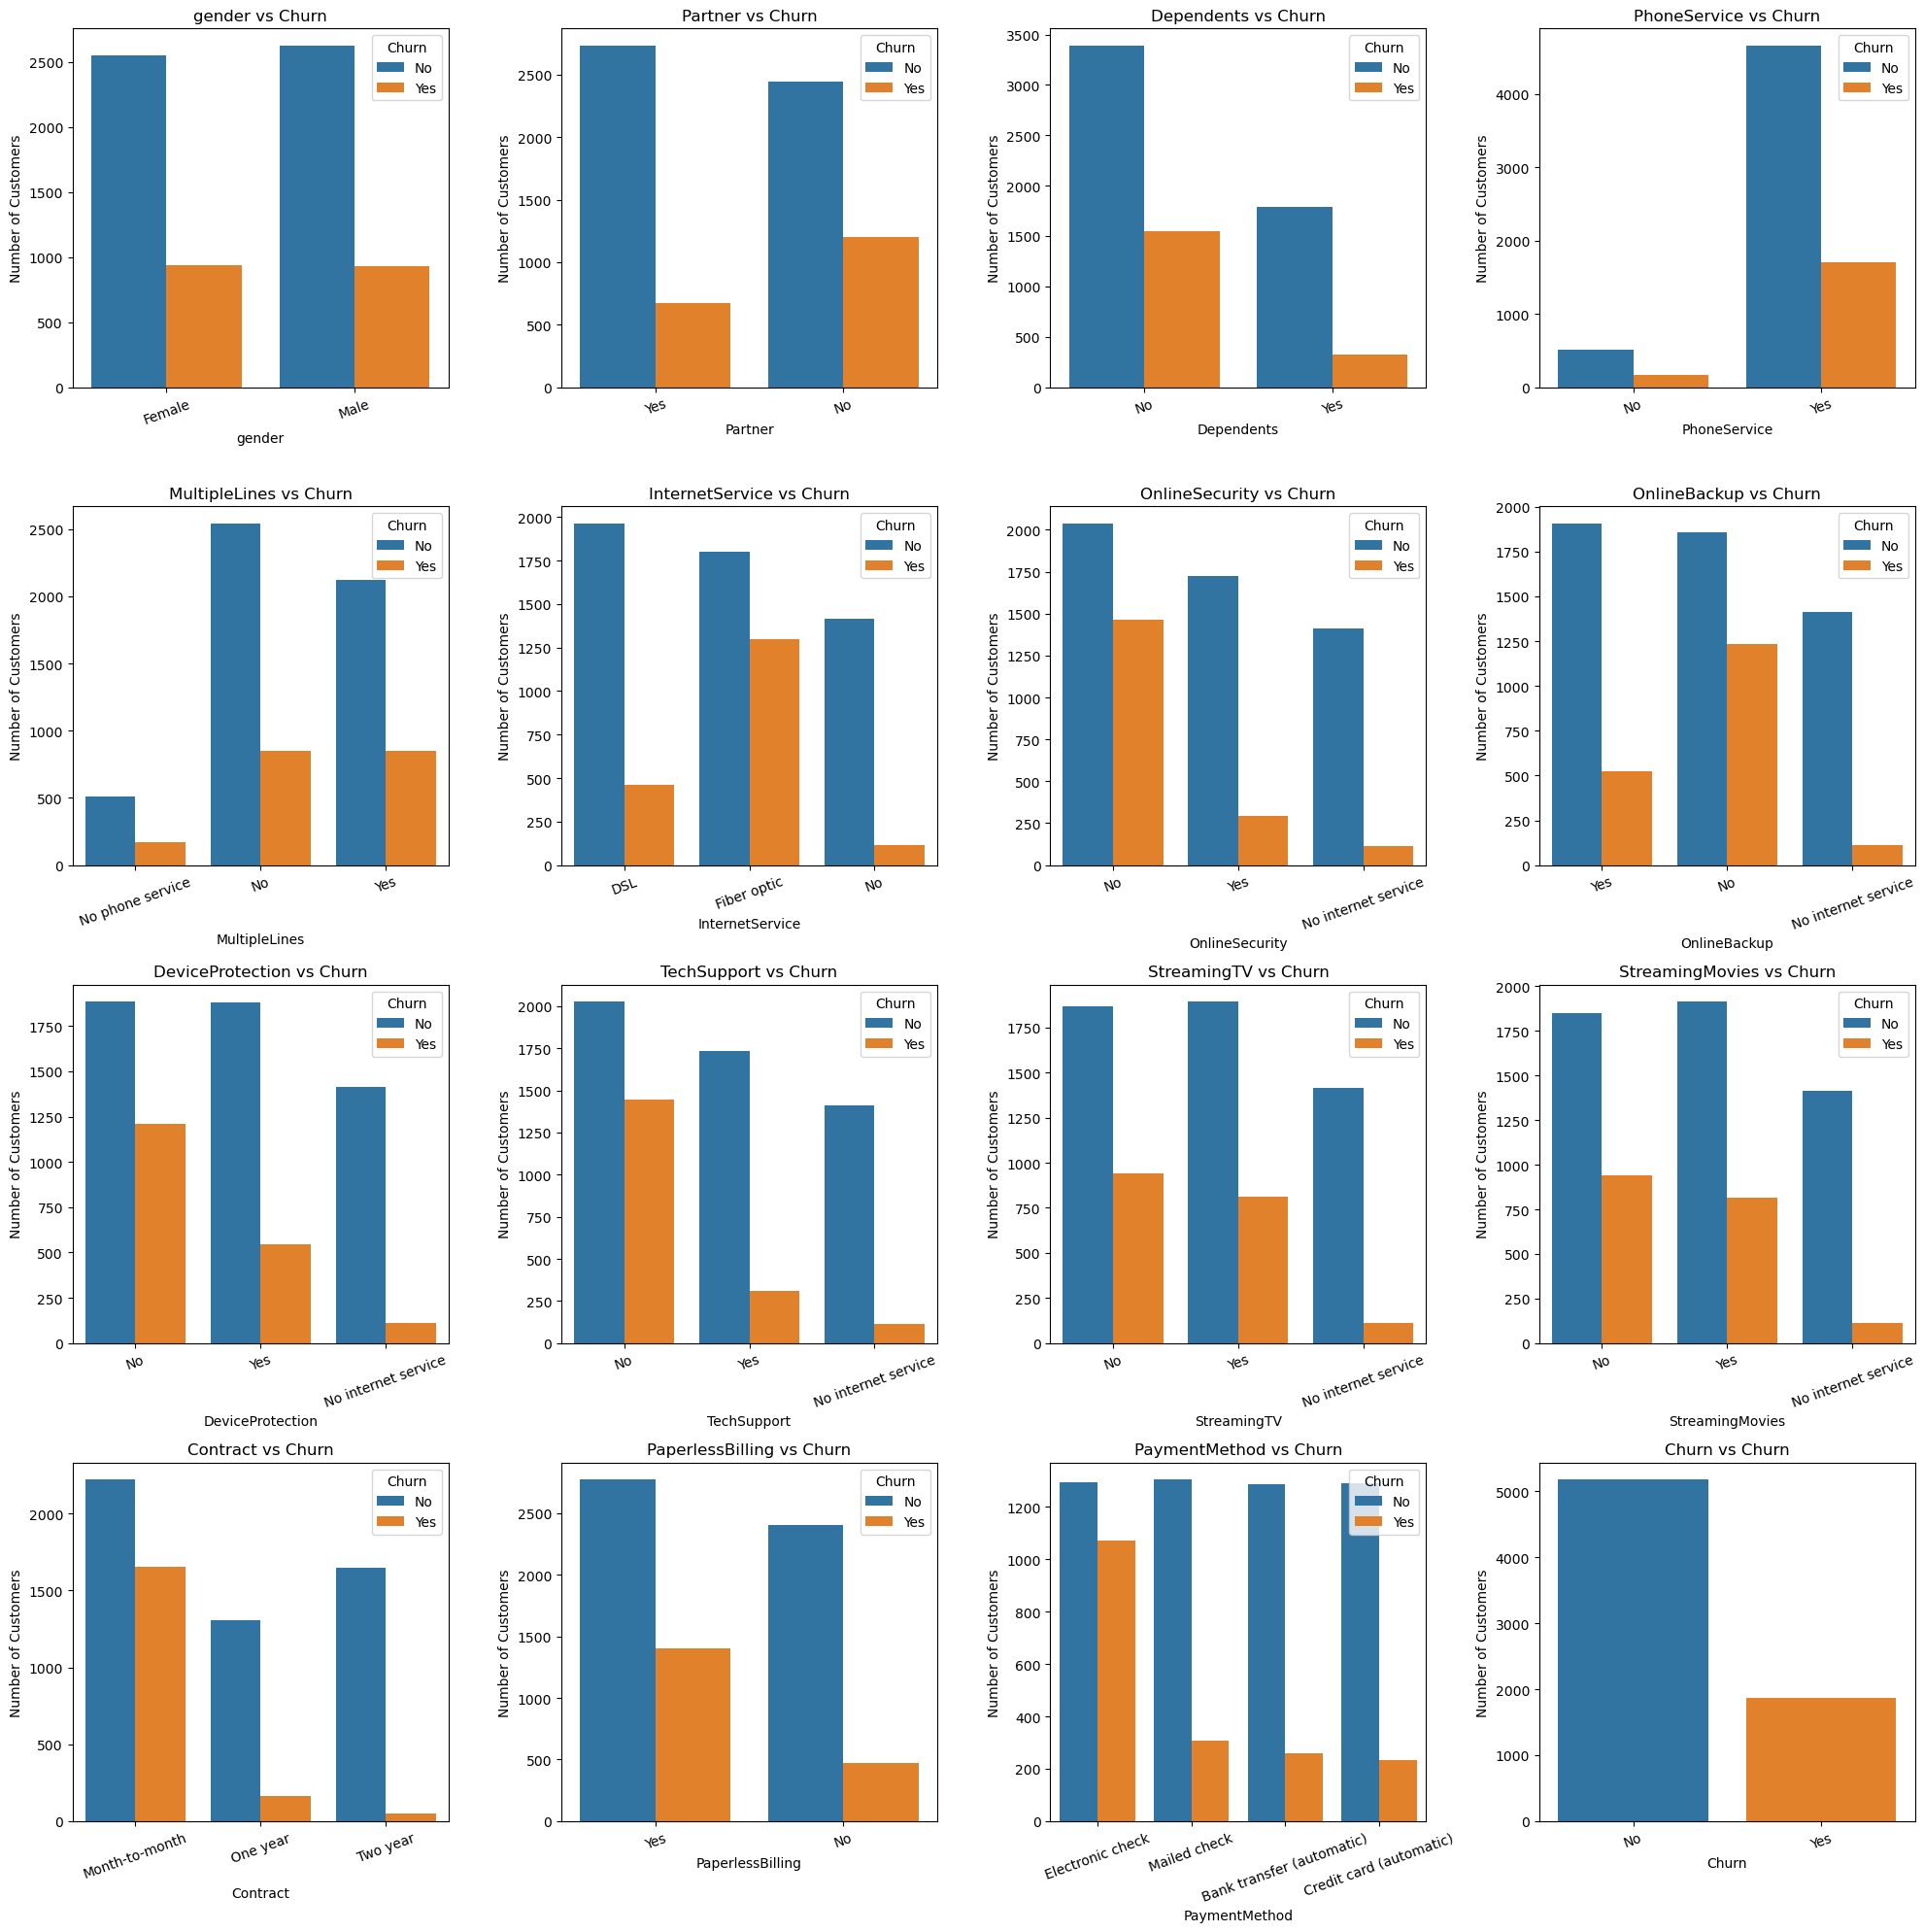

In [29]:
categorical_features = df.select_dtypes(include="object").columns.drop(
    ["customerID", "TotalCharges"]
)

n_cols = 4
n_rows = (len(categorical_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(20, n_rows * 5)
)

axes = axes.flatten()

for i, column in enumerate(categorical_features):

    sns.countplot(
        data=df,
        x=column,
        hue="Churn",
        ax=axes[i]
    )

    axes[i].set_title(f"{column} vs Churn")
    axes[i].set_xlabel(column)
    axes[i].set_ylabel("Number of Customers")
    axes[i].tick_params(axis="x", rotation=20)

# Empty plots hide
for i in range(len(categorical_features), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

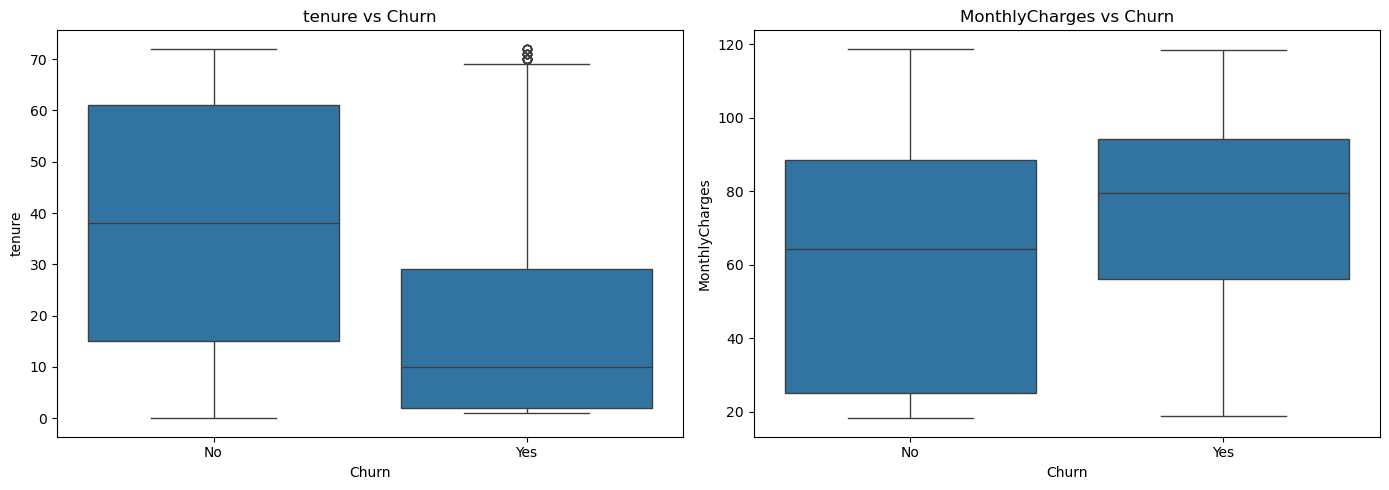

In [30]:
# Numerical Features vs Churn 

numerical_features = ["tenure", "MonthlyCharges"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, column in zip(axes, numerical_features):

    sns.boxplot(
        data=df,
        x="Churn",
        y=column,
        ax=ax
    )

    ax.set_title(f"{column} vs Churn")
    ax.set_xlabel("Churn")
    ax.set_ylabel(column)

plt.tight_layout()
plt.show()

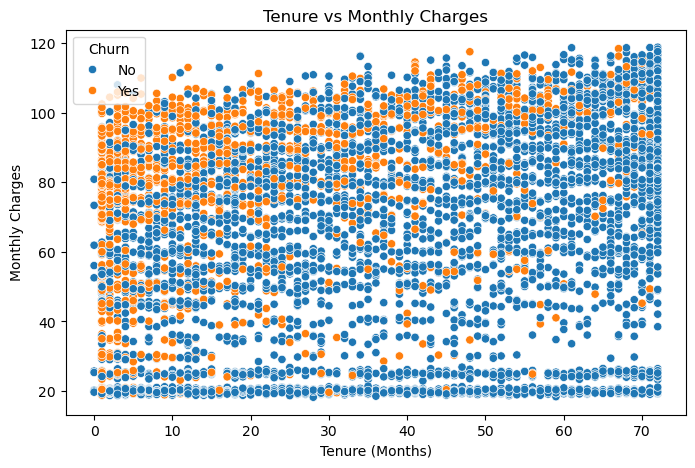

In [31]:
# Bivariate Analysis → Numerical vs Numerical

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="tenure",
    y="MonthlyCharges",
    hue="Churn"
)

plt.title("Tenure vs Monthly Charges")
plt.xlabel("Tenure (Months)")
plt.ylabel("Monthly Charges")

plt.show()

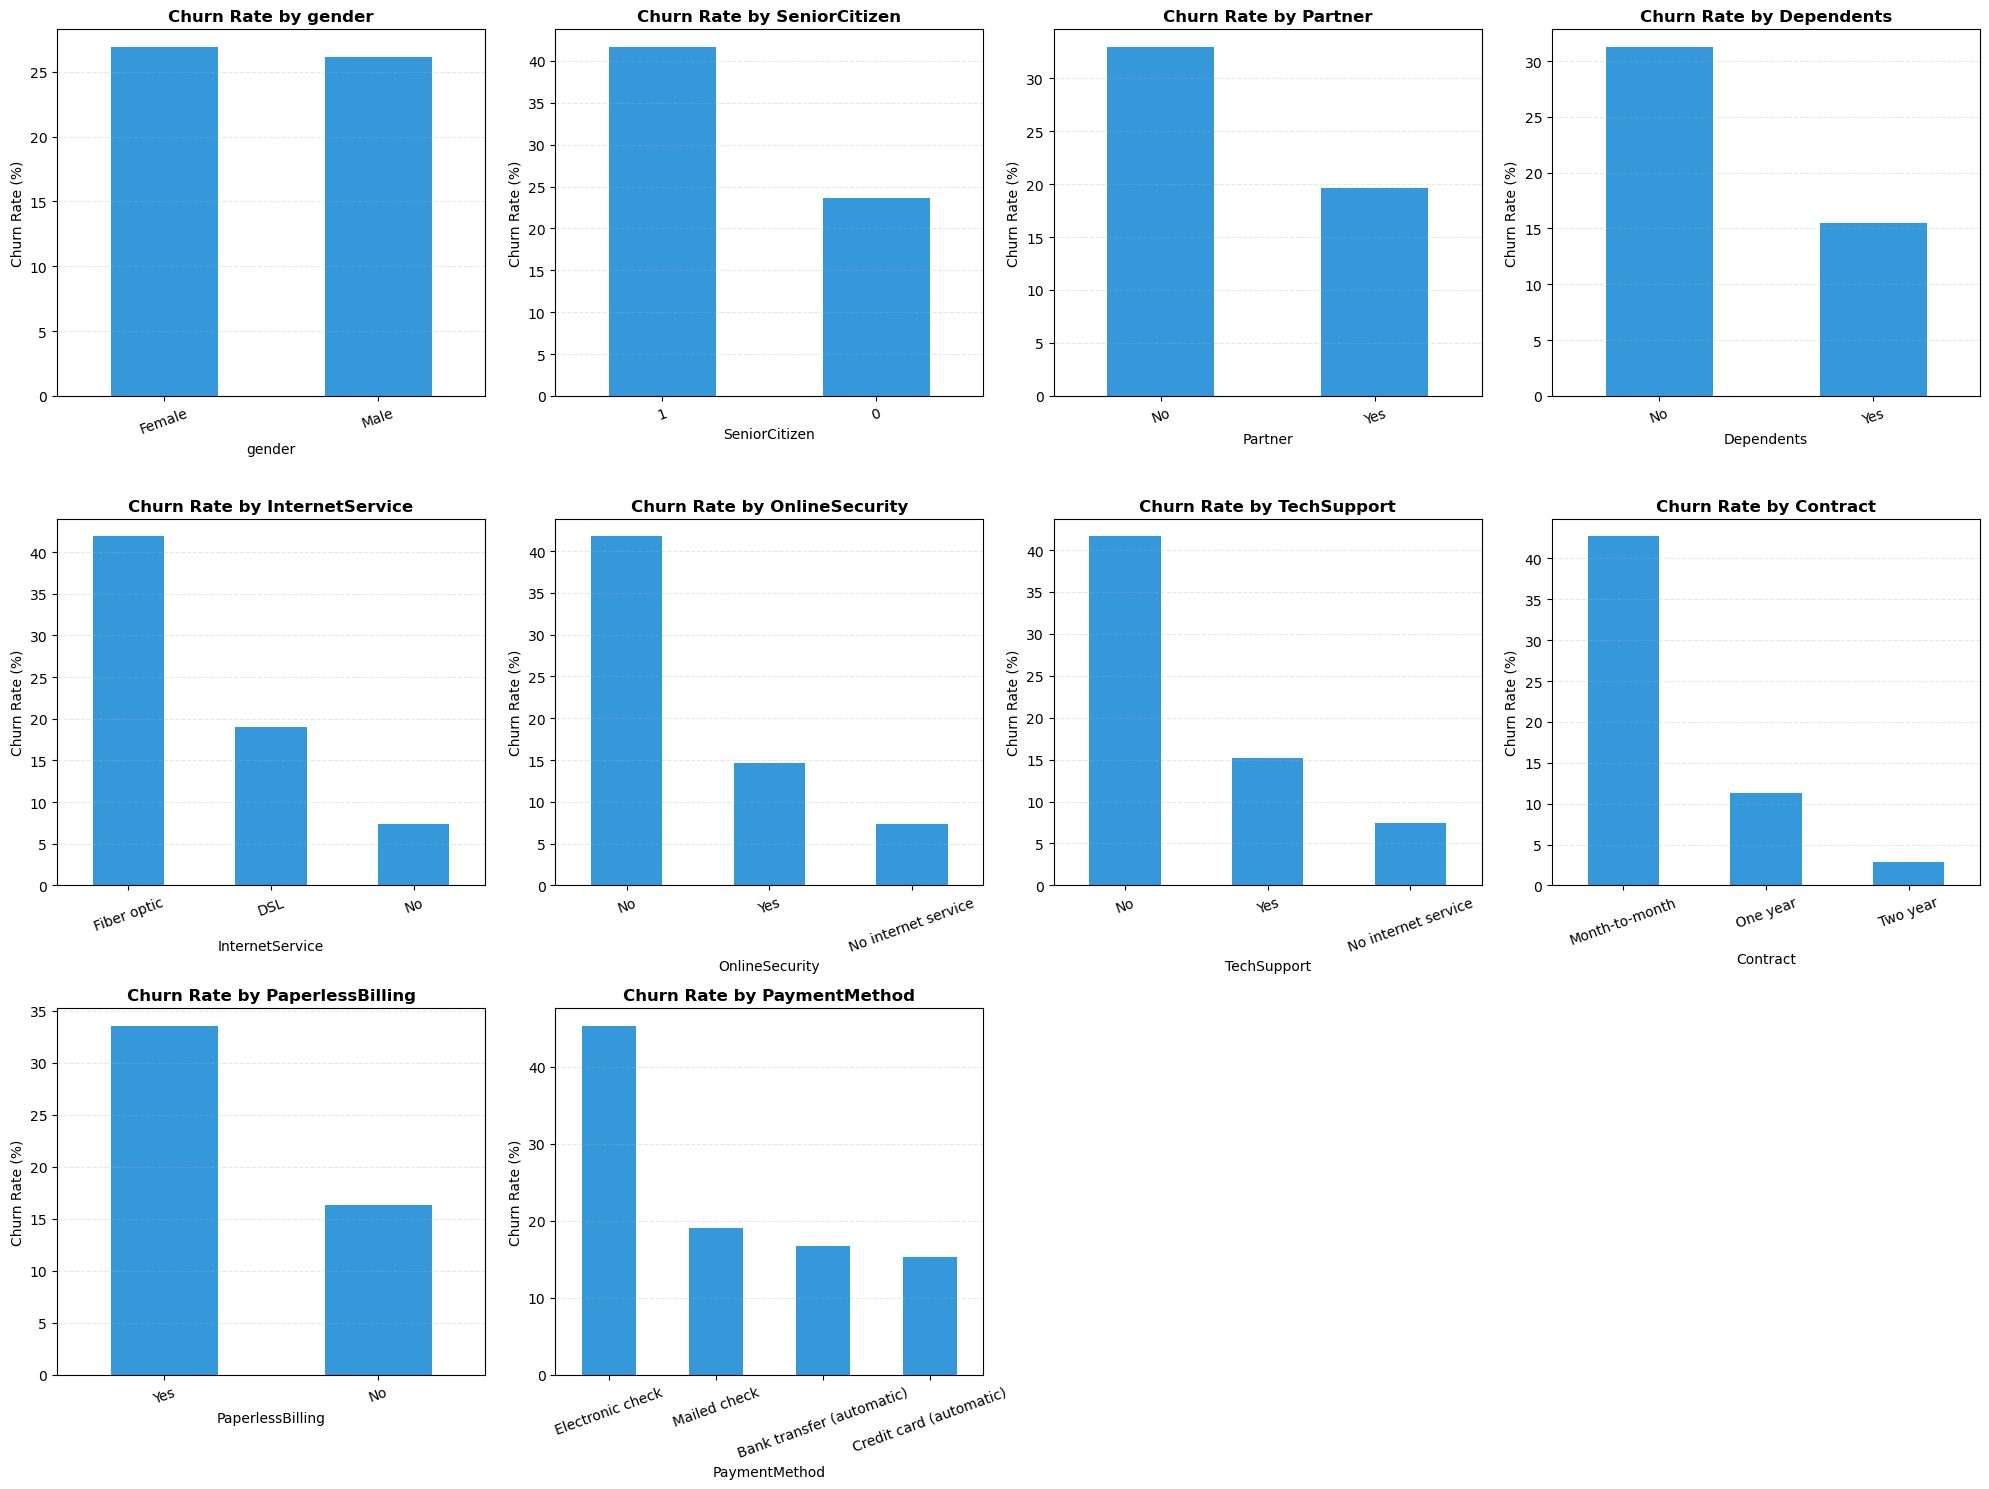

In [32]:
# Bivariate Analysis → Churn Rate

important_features = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "InternetService",
    "OnlineSecurity",
    "TechSupport",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

n_cols = 4
n_rows = (len(important_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(20, 15)
)

axes = axes.flatten()

for i, column in enumerate(important_features):

    churn_rate = (
        df.groupby(column)["Churn"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .sort_values(ascending=False)
    )

    churn_rate.plot(
        kind="bar",
        ax=axes[i],
        color="#3498DB"
    )

    axes[i].set_title(
        f"Churn Rate by {column}",
        fontsize=12,
        fontweight="bold"
    )

    axes[i].set_xlabel(column)
    axes[i].set_ylabel("Churn Rate (%)")
    axes[i].tick_params(axis="x", rotation=20)

    axes[i].grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )

# Empty plots hide
for i in range(len(important_features), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

# Step 10 → Multivariate Analysis

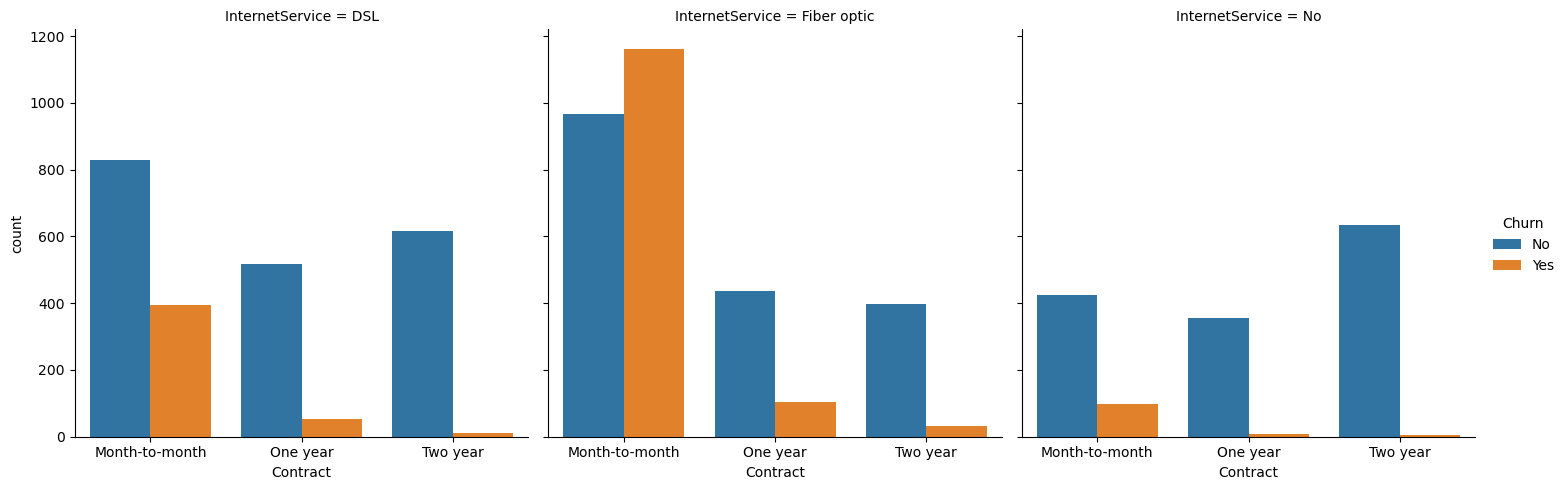

In [33]:
# 10.1 → Contract + InternetService + Churn

sns.catplot(
    data=df,
    x="Contract",
    hue="Churn",
    col="InternetService",
    kind="count",
    height=5,
    aspect=1
)

plt.show()

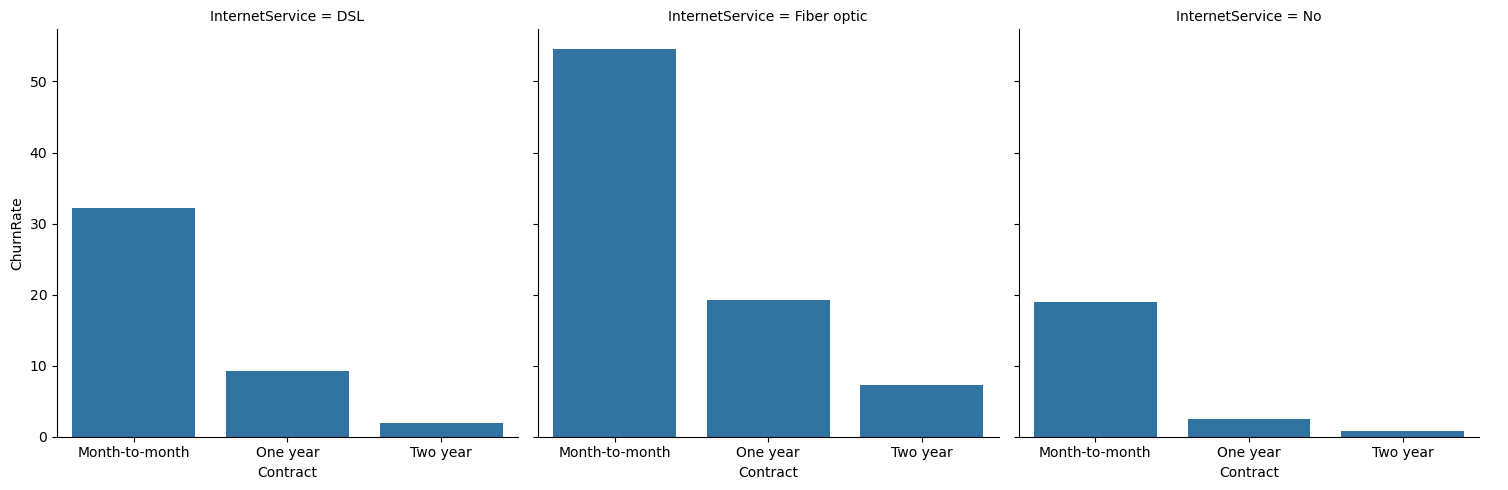

In [34]:
# Step 10.2 → Multivariate Analysis
# Contract + InternetService + Churn Rate

multivariate_data = (
    df.groupby(["Contract", "InternetService"])["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

sns.catplot(
    data=multivariate_data,
    x="Contract",
    y="ChurnRate",
    col="InternetService",
    kind="bar",
    height=5,
    aspect=1
)

plt.show()

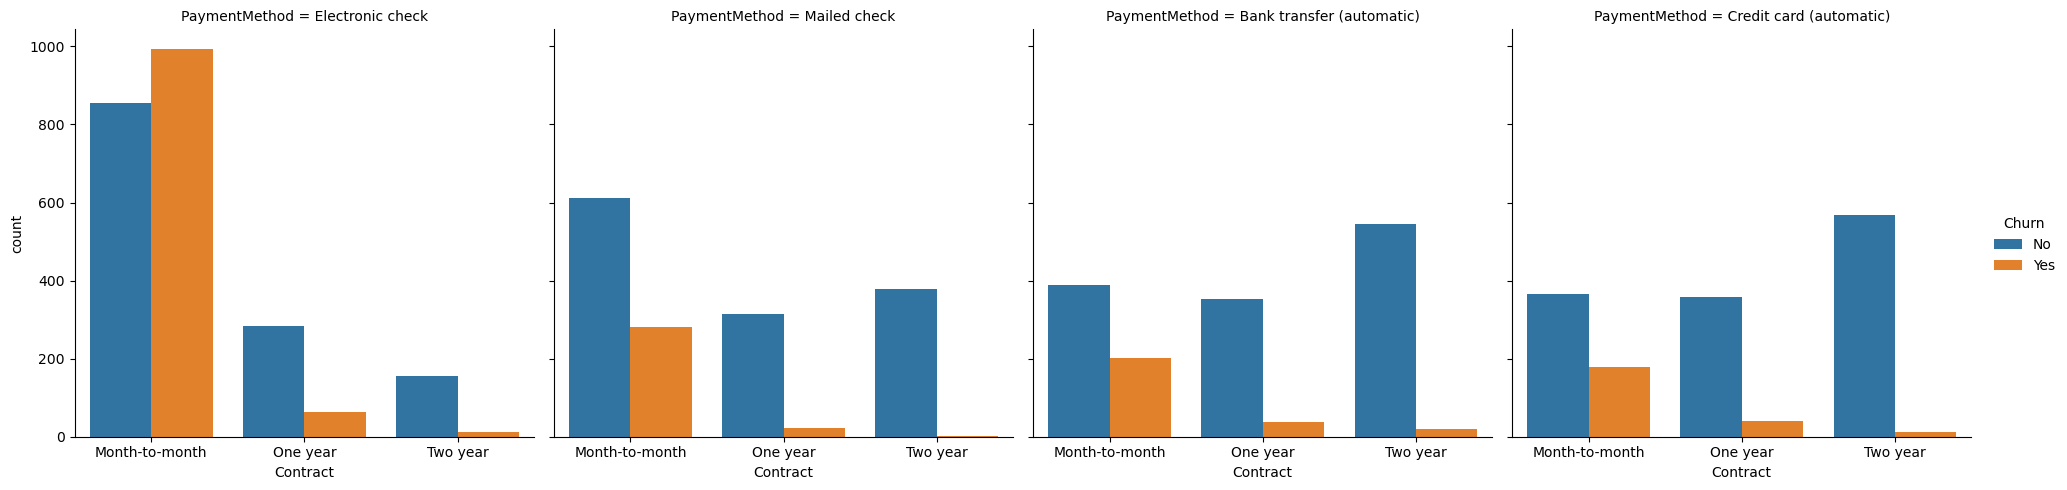

In [35]:
# Step 10.3 → Multivariate Analysis
# Contract + PaymentMethod + Churn

sns.catplot(
    data=df,
    x="Contract",
    hue="Churn",
    col="PaymentMethod",
    kind="count",
    height=5,
    aspect=1
)

plt.show()

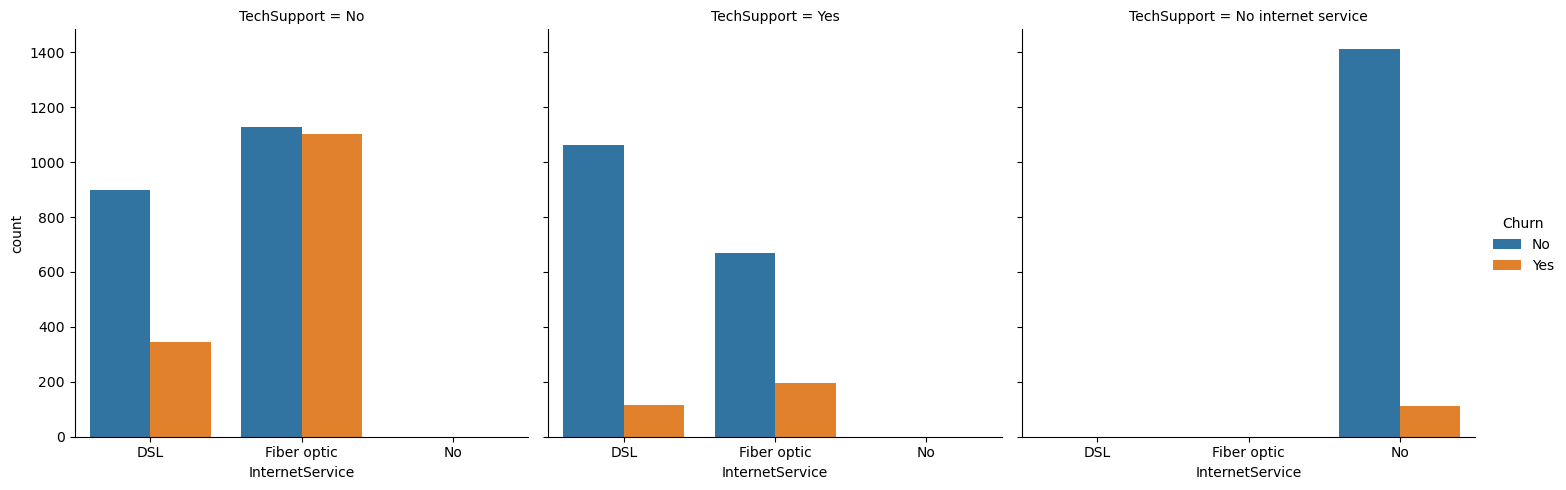

In [36]:
# Step 10.4 → Multivariate Analysis
# InternetService + TechSupport + Churn

sns.catplot(
    data=df,
    x="InternetService",
    hue="Churn",
    col="TechSupport",
    kind="count",
    height=5,
    aspect=1
)

plt.show()

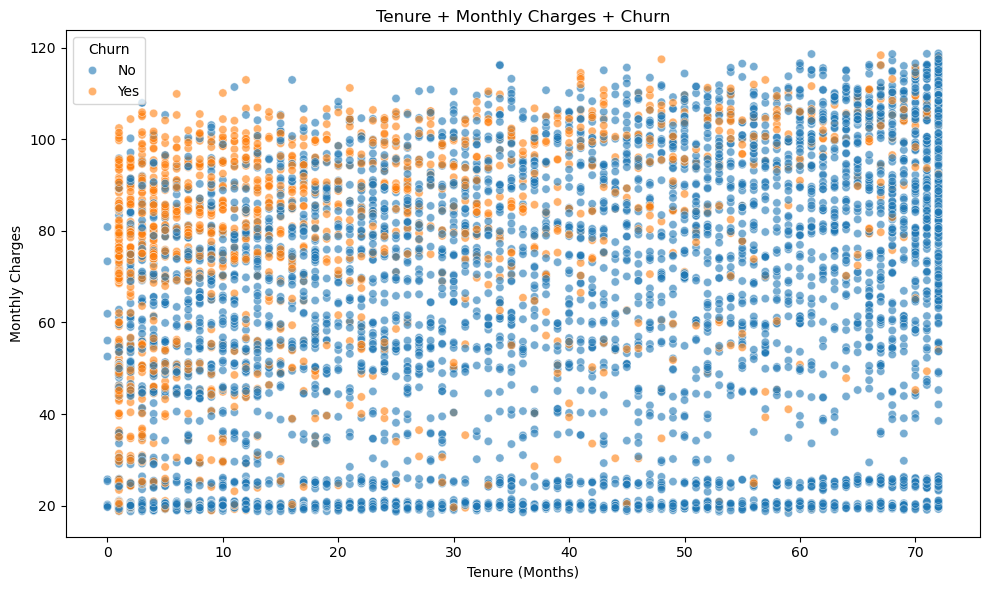

In [37]:
# Step 10.5 → Multivariate Analysis
# Tenure + MonthlyCharges + Churn

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="tenure",
    y="MonthlyCharges",
    hue="Churn",
    alpha=0.6
)

plt.title("Tenure + Monthly Charges + Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Monthly Charges")

plt.tight_layout()
plt.show()

# Step 11 → Correlation Analysis

In [38]:
# Select numerical columns
numerical_df = df.select_dtypes(include="number")

# Correlation Matrix
correlation_matrix = numerical_df.corr()

correlation_matrix

,SeniorCitizen,tenure,MonthlyCharges
SeniorCitizen,1.000000,0.016567,0.220173
tenure,0.016567,1.000000,0.247900
MonthlyCharges,0.220173,0.247900,1.000000


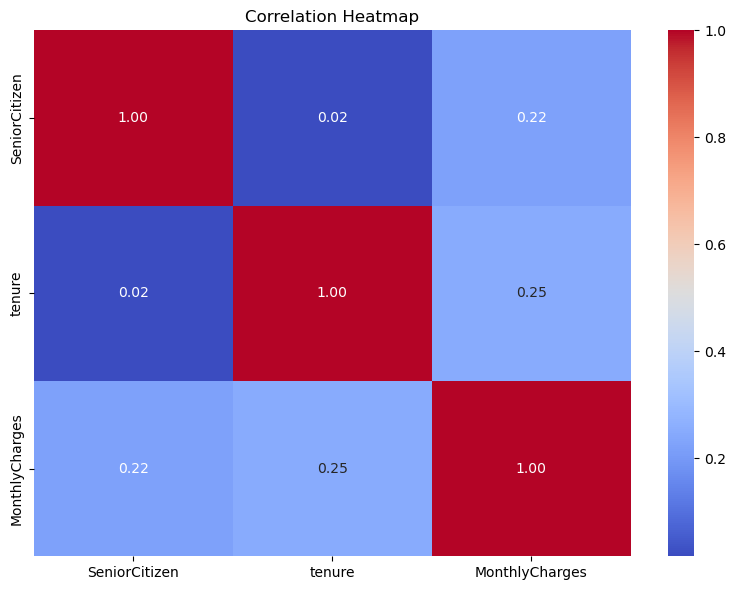

In [39]:
# Step 11.2 → Correlation Heatmap

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

In [40]:
# Step 11.3 → Convert TotalCharges to Numerical

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"].dtype

dtype('float64')

In [41]:
# Check missing values after conversion

df["TotalCharges"].isnull().sum()

np.int64(11)

In [42]:
# Step 11.4 → Updated Correlation Matrix

numerical_df = df.select_dtypes(include="number")

correlation_matrix = numerical_df.corr()

correlation_matrix

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.016567,0.220173,0.102411
tenure,0.016567,1.000000,0.247900,0.825880
MonthlyCharges,0.220173,0.247900,1.000000,0.651065
TotalCharges,0.102411,0.825880,0.651065,1.000000


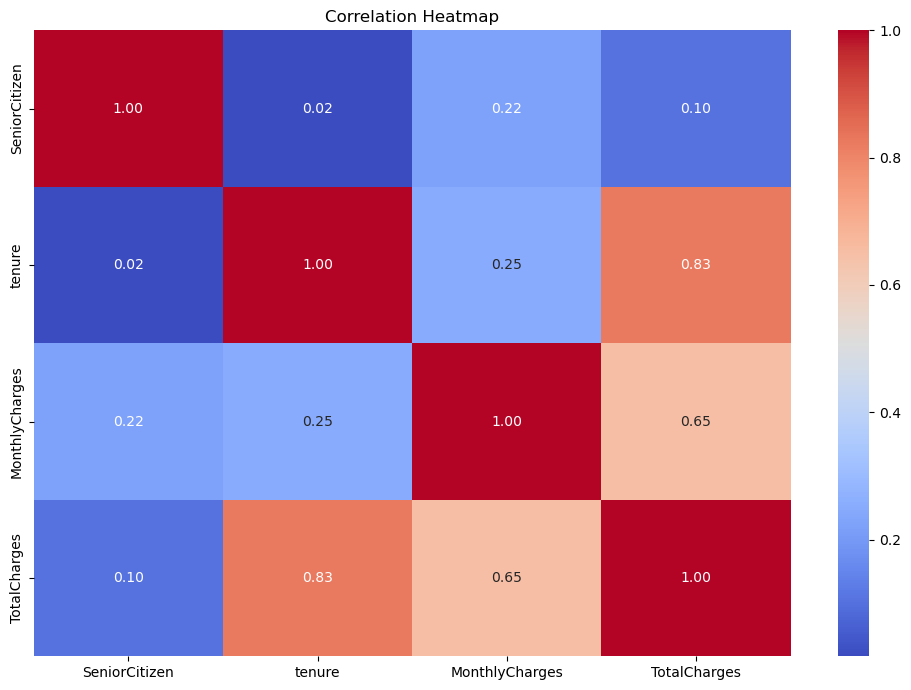

In [43]:
# Step 11.5 → Updated Correlation Heatmap

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

# Step 12 → Business Insights

In [44]:
# Overall Churn Rate

churn_rate = (
    df["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Overall Churn Rate:")
print(churn_rate)

Overall Churn Rate:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


In [45]:
# Contract-wise Churn Rate

contract_churn = (
    df.groupby("Contract")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
    .sort_values(ascending=False)
)

print("Churn Rate by Contract:")
print(contract_churn)

Churn Rate by Contract:
Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Churn, dtype: float64


In [46]:
# Internet Service-wise Churn Rate

internet_churn = (
    df.groupby("InternetService")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
    .sort_values(ascending=False)
)

print("Churn Rate by Internet Service:")
print(internet_churn)

Churn Rate by Internet Service:
InternetService
Fiber optic    41.89
DSL            18.96
No              7.40
Name: Churn, dtype: float64


In [47]:
# Step 12.2 → Business Insight → Contract vs Churn

contract_churn = (
    df.groupby("Contract")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
    .sort_values(ascending=False)
)

print("Churn Rate by Contract:")
print(contract_churn)

Churn Rate by Contract:
Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Churn, dtype: float64


In [48]:
# Step 12.3 → Business Insight → PaymentMethod vs Churn

payment_churn = (
    df.groupby("PaymentMethod")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
    .sort_values(ascending=False)
)

print("Churn Rate by Payment Method:")
print(payment_churn)

Churn Rate by Payment Method:
PaymentMethod
Electronic check             45.29
Mailed check                 19.11
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Name: Churn, dtype: float64


In [49]:
# Step 12.4 → Business Insight → TechSupport vs Churn

techsupport_churn = (
    df.groupby("TechSupport")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
    .sort_values(ascending=False)
)

print("Churn Rate by TechSupport:")
print(techsupport_churn)

Churn Rate by TechSupport:
TechSupport
No                     41.64
Yes                    15.17
No internet service     7.40
Name: Churn, dtype: float64


In [50]:
# Step 12.5 → Business Insight → OnlineSecurity vs Churn

onlinesecurity_churn = (
    df.groupby("OnlineSecurity")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
    .sort_values(ascending=False)
)

print("Churn Rate by OnlineSecurity:")
print(onlinesecurity_churn)

Churn Rate by OnlineSecurity:
OnlineSecurity
No                     41.77
Yes                    14.61
No internet service     7.40
Name: Churn, dtype: float64


In [51]:
# ============================================================
# Step 12 → Business Insights → Remaining Features
# ============================================================

features = [
    "OnlineBackup",
    "DeviceProtection",
    "StreamingTV",
    "StreamingMovies"
]

for column in features:

    churn_rate = (
        df.groupby(column)["Churn"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .round(2)
        .sort_values(ascending=False)
    )

    print("\n" + "=" * 50)
    print(f"Churn Rate by {column}")
    print("=" * 50)
    print(churn_rate)


Churn Rate by OnlineBackup
OnlineBackup
No                     39.93
Yes                    21.53
No internet service     7.40
Name: Churn, dtype: float64

Churn Rate by DeviceProtection
DeviceProtection
No                     39.13
Yes                    22.50
No internet service     7.40
Name: Churn, dtype: float64

Churn Rate by StreamingTV
StreamingTV
No                     33.52
Yes                    30.07
No internet service     7.40
Name: Churn, dtype: float64

Churn Rate by StreamingMovies
StreamingMovies
No                     33.68
Yes                    29.94
No internet service     7.40
Name: Churn, dtype: float64


In [52]:
# Churn vs Tenure

print(
    df.groupby("Churn")["tenure"]
    .mean()
    .round(2)
)

Churn
No     37.57
Yes    17.98
Name: tenure, dtype: float64


In [53]:
# Churn vs Monthly Charges

print(
    df.groupby("Churn")["MonthlyCharges"]
    .mean()
    .round(2)
)

Churn
No     61.27
Yes    74.44
Name: MonthlyCharges, dtype: float64


# Missing Value Treatment → TotalCharges

In [54]:
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

print("Missing Values after Imputation:")
print(df["TotalCharges"].isnull().sum())

Missing Values after Imputation:
0


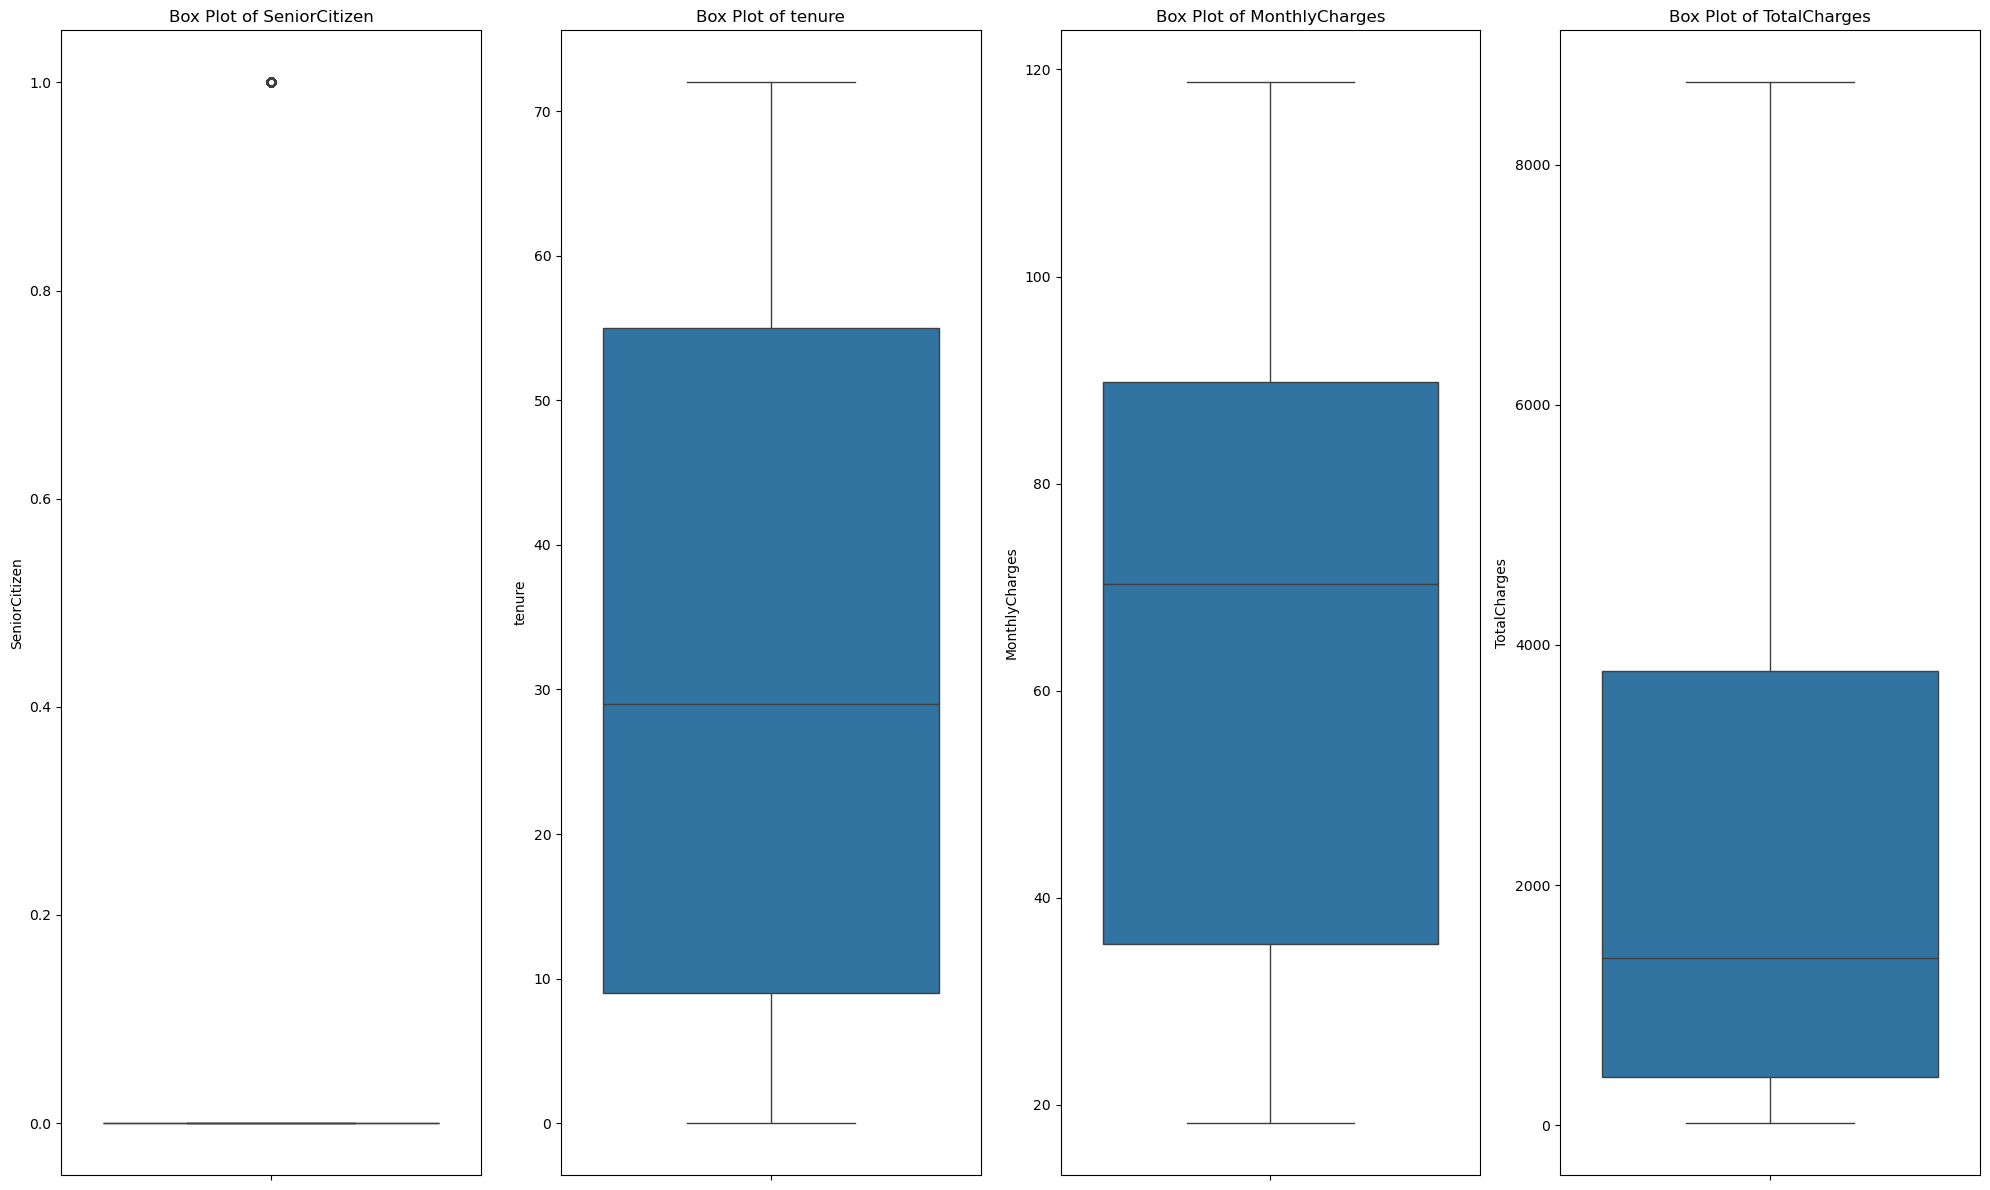

In [55]:
# ============================================================
# Step 13 → Outlier Analysis → Box Plot
# ============================================================

numerical_columns = df.select_dtypes(include="number").columns

n_cols = 4
n_rows = (len(numerical_columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(20, 12)
)

axes = axes.flatten()

for i, column in enumerate(numerical_columns):

    sns.boxplot(
        data=df,
        y=column,
        ax=axes[i]
    )

    axes[i].set_title(f"Box Plot of {column}")

# Empty plots hide
for i in range(len(numerical_columns), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

# FINAL DATA CLEANING CHECK

In [56]:
# Shape
print("\n1. Dataset Shape:")
print(df.shape)

# Missing Values
print("\n2. Missing Values:")
print(df.isnull().sum().sum())

# Duplicates
print("\n3. Duplicate Rows:")
print(df.duplicated().sum())

# Blank Values
blank_count = 0

for column in df.columns:
    blank_count += (
        df[column].astype(str).str.strip() == ""
    ).sum()

print("\n4. Blank Values:")
print(blank_count)

# Infinite Values
infinite_count = np.isinf(
    df.select_dtypes(include="number")
).sum().sum()

print("\n5. Infinite Values:")
print(infinite_count)

# Data Types
print("\n6. Data Types:")
print(df.dtypes)

print("\n" + "=" * 60)
print("CHECK COMPLETE")
print("=" * 60)


1. Dataset Shape:
(7043, 21)

2. Missing Values:
0

3. Duplicate Rows:
0

4. Blank Values:
0


NameError: name 'np' is not defined

In [ ]:
# Save cleaned dataset
df.to_csv("churn_cleaned.csv", index=False)
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
